# U-path comparison: flat enumeration vs graph walks

U-path geometry over the table graph:

```
(0,j) col_header_j        col_header_k (0,k)
      │ down                        ↑ up
(i,j) cell_a  ──right──►  cell_b (i,k)
```

Graph walk: `(0,j) down► (i,j) right► (i,k) up► (0,k)`  
Text: `col_header_j | cell_a | cell_b | col_header_k`

| Generator | Description |
|-----------|-------------|
| `generate_u_paths_flat` | exhaustive enumeration — every row × every column pair |
| `generate_u_paths_from_graph` | sampled via SemanticMetaPath graph walks |

In [1]:
import sys, pathlib

_HERE = pathlib.Path().resolve()
_TRL  = _HERE if (_HERE / "smp.py").exists() else _HERE / "TRL-model"
if str(_TRL) not in sys.path:
    sys.path.insert(0, str(_TRL))

from smp import (
    UPath,
    generate_u_paths_flat, generate_u_paths_from_graph,
)

## Sample table

A small WikiSQL-style table used for all comparisons below.  
Swap in any real table from `datasets/qa.jsonl` to test on live data.

In [2]:
header = ["Player", "Country", "Score", "Rank"]
rows   = [
    ["Alice",   "Belgium",     "95",  "1"],
    ["Bob",     "France",      "88",  "2"],
    ["Charlie", "Netherlands", "82",  "3"],
    ["Diana",   "Germany",     "79",  "4"],
]

# SMP generation
# Player down Alice right Belgium up Country (UPath: Player → Country)
# ID (0,0),(1,0), (1,1),(0,1) 
#Upath Country --> Player is also valid, but the above is more intuitive to read and write


# Player down Alice right Belgium up Score (UPath: Player → Score)
# ID (0,0),(1,0), (1,2),(0,2) 

# Player down Bob right France up Country (UPath: Player → Country)
#ID (0,0),(2,0), (2,1),(0,1) 

# Player down Alice right 1 up Rank (UPath: Player → Rank)
# ID (0,0),(1,0), (1,3),(0,3) 

# ── Optional: load a real record from the dataset ─────────────────────────
# import json, pathlib
# line   = (pathlib.Path(_TRL).parent / "datasets/qa.jsonl").read_text().splitlines()[0]
# record = json.loads(line)
# header = record["header"]
# rows   = [list(map(str, r)) for r in record["rows"]]
# print("question:", record.get("question", "n/a"))

print(f"Table: {len(rows)} rows × {len(header)} cols")
print("Header:", header)
for r in rows:
    print(" ", r)

Table: 4 rows × 4 cols
Header: ['Player', 'Country', 'Score', 'Rank']
  ['Alice', 'Belgium', '95', '1']
  ['Bob', 'France', '88', '2']
  ['Charlie', 'Netherlands', '82', '3']
  ['Diana', 'Germany', '79', '4']


## Generate U-paths — flat and graph modes

In [3]:
import pandas as pd

u_flat  = generate_u_paths_flat(header, rows)
u_graph = generate_u_paths_from_graph(header, rows, num_walks=50, chunk_size=1)

n_rows_t, n_cols_t = len(rows), len(header)
expected_u = n_rows_t * (n_cols_t * (n_cols_t - 1) // 2)   # rows × C(cols,2)

print(f"U-path  without graph : {len(u_flat):>4}  paths")
print(f"U-path  with graph    : {len(u_graph):>4}  paths")
print(f"Expected (rows × C(cols,2)) = {expected_u}")

U-path  without graph :   24  paths
U-path  with graph    :    3  paths
Expected (rows × C(cols,2)) = 24


In [4]:
print(f"U-paths (without graph) — {len(u_flat)} total\n")
for u in u_flat:
    print(f"  [{u.pivot_a} → {u.node_a} → {u.node_b} → {u.pivot_b}]")
    print(f"    forward : {u.smp_text}")
    print(f"    reverse : {u.reversed_smp_text}")
    print()

U-paths (without graph) — 24 total

  [0,0 → 1,0 → 1,1 → 0,1]
    forward : Player | Alice | Belgium | Country
    reverse : Country | Belgium | Alice | Player

  [0,0 → 1,0 → 1,2 → 0,2]
    forward : Player | Alice | 95 | Score
    reverse : Score | 95 | Alice | Player

  [0,0 → 1,0 → 1,3 → 0,3]
    forward : Player | Alice | 1 | Rank
    reverse : Rank | 1 | Alice | Player

  [0,1 → 1,1 → 1,2 → 0,2]
    forward : Country | Belgium | 95 | Score
    reverse : Score | 95 | Belgium | Country

  [0,1 → 1,1 → 1,3 → 0,3]
    forward : Country | Belgium | 1 | Rank
    reverse : Rank | 1 | Belgium | Country

  [0,2 → 1,2 → 1,3 → 0,3]
    forward : Score | 95 | 1 | Rank
    reverse : Rank | 1 | 95 | Score

  [0,0 → 2,0 → 2,1 → 0,1]
    forward : Player | Bob | France | Country
    reverse : Country | France | Bob | Player

  [0,0 → 2,0 → 2,2 → 0,2]
    forward : Player | Bob | 88 | Score
    reverse : Score | 88 | Bob | Player

  [0,0 → 2,0 → 2,3 → 0,3]
    forward : Player | Bob | 2 | Rank
  

---
## U-path output table

Each U-path connects **two cells** through a shared pivot (column header or row header).

In [5]:
def upaths_to_df(upaths, label):
    """Columns come directly from UPath.__post_init__ fields."""
    return pd.DataFrame([{
        "mode":              label,
        "pivot_a":           u.pivot_a,
        "node_a":            u.node_a,
        "col_idx_a":         u.col_idx_a,
        "col_header_a":      u.col_header_a,
        "cell_a":            u.cell_value_a,
        "cell_b":            u.cell_value_b,
        "col_header_b":      u.col_header_b,
        "col_idx_b":         u.col_idx_b,
        "node_b":            u.node_b,
        "pivot_b":           u.pivot_b,
        "tbl_row":           u.tbl_row,
        "smp_text":          u.smp_text,
        "reversed_smp_text": u.reversed_smp_text,
    } for u in upaths])

df_u_flat  = upaths_to_df(u_flat,  "without graph")
df_u_graph = upaths_to_df(u_graph, "with graph")

print("=== U-path without graph ===")
display(df_u_flat.style.set_properties(**{"text-align": "left"}))

print("\n=== U-path with graph ===")
display(df_u_graph.style.set_properties(**{"text-align": "left"}))

=== U-path without graph ===


,mode,pivot_a,node_a,col_idx_a,col_header_a,cell_a,cell_b,col_header_b,col_idx_b,node_b,pivot_b,tbl_row,smp_text,reversed_smp_text
0,without graph,"0,0","1,0",0,Player,Alice,Belgium,Country,1,"1,1","0,1",1,Player | Alice | Belgium | Country,Country | Belgium | Alice | Player
1,without graph,"0,0","1,0",0,Player,Alice,95,Score,2,"1,2","0,2",1,Player | Alice | 95 | Score,Score | 95 | Alice | Player
2,without graph,"0,0","1,0",0,Player,Alice,1,Rank,3,"1,3","0,3",1,Player | Alice | 1 | Rank,Rank | 1 | Alice | Player
3,without graph,"0,1","1,1",1,Country,Belgium,95,Score,2,"1,2","0,2",1,Country | Belgium | 95 | Score,Score | 95 | Belgium | Country
4,without graph,"0,1","1,1",1,Country,Belgium,1,Rank,3,"1,3","0,3",1,Country | Belgium | 1 | Rank,Rank | 1 | Belgium | Country
5,without graph,"0,2","1,2",2,Score,95,1,Rank,3,"1,3","0,3",1,Score | 95 | 1 | Rank,Rank | 1 | 95 | Score
6,without graph,"0,0","2,0",0,Player,Bob,France,Country,1,"2,1","0,1",2,Player | Bob | France | Country,Country | France | Bob | Player
7,without graph,"0,0","2,0",0,Player,Bob,88,Score,2,"2,2","0,2",2,Player | Bob | 88 | Score,Score | 88 | Bob | Player
8,without graph,"0,0","2,0",0,Player,Bob,2,Rank,3,"2,3","0,3",2,Player | Bob | 2 | Rank,Rank | 2 | Bob | Player
9,without graph,"0,1","2,1",1,Country,France,88,Score,2,"2,2","0,2",2,Country | France | 88 | Score,Score | 88 | France | Country



=== U-path with graph ===


,mode,pivot_a,node_a,col_idx_a,col_header_a,cell_a,cell_b,col_header_b,col_idx_b,node_b,pivot_b,tbl_row,smp_text,reversed_smp_text
0,with graph,"0,1","1,1",1,Country,Belgium,95,Score,2,"1,2","0,2",1,Country | Belgium | 95 | Score,Score | 95 | Belgium | Country
1,with graph,"0,2","1,2",2,Score,95,1,Rank,3,"1,3","0,3",1,Score | 95 | 1 | Rank,Rank | 1 | 95 | Score
2,with graph,"0,0","1,0",0,Player,Alice,Belgium,Country,1,"1,1","0,1",1,Player | Alice | Belgium | Country,Country | Belgium | Alice | Player


## U-path count: flat vs graph

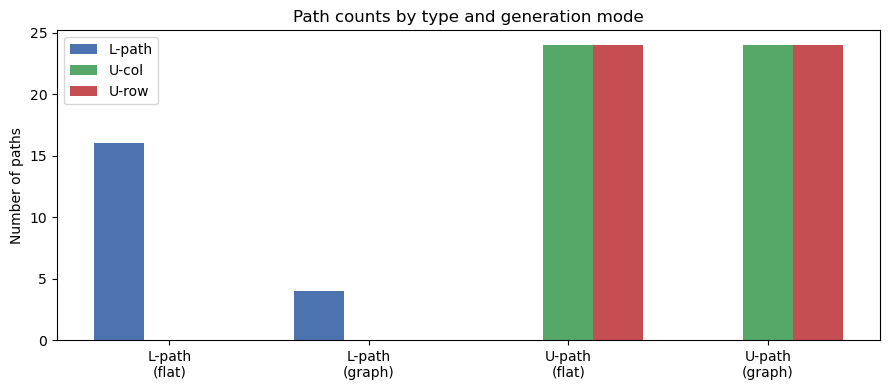

In [ ]:
import matplotlib.pyplot as plt

labels  = ["without graph", "with graph"]
counts  = [len(u_flat), len(u_graph)]

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(labels, counts, color=["#55A868", "#4C72B0"])
ax.set_ylabel("Number of U-paths")
ax.set_title("U-path counts: flat enumeration vs graph walks")
for i, c in enumerate(counts):
    ax.text(i, c + 0.3, str(c), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()